In [ ]:
# ============================================================
# الخلية 1: المكتبات والإعدادات (نسخة Jupyter المحلية)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, re, time, math, warnings
from scipy.linalg import sqrtm, inv
from scipy.stats import kurtosis, skew, entropy, ttest_ind
from scipy.interpolate import griddata
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (16, 6)
sns.set_style('whitegrid')

# ── إعدادات الشبكة ───────────────────────────────────────────
ROWS, COLS         = 34, 16
CENTER_ROW         = 16.5
CENTER_COL         = 7.5
RADIUS             = 6.0
EPS                = 1e-10
WEIGHT_THRESHOLD   = 0.01
STABLE_WINDOW_TRIM = 0.20

# ── القناع الدائري ────────────────────────────────────────────
_ri, _ci = np.indices((ROWS, COLS))
MASK_2D  = np.sqrt((_ri - CENTER_ROW)**2 + (_ci - CENTER_COL)**2) <= RADIUS
N_ACTIVE_PIXELS = int(MASK_2D.sum())

# ── إحداثيات ثابتة (تُحسب مرة واحدة) ────────────────────────
_y_idx, _x_idx = np.indices((ROWS, COLS))
COORDS_FLAT     = np.stack([_x_idx.ravel(), _y_idx.ravel()], axis=0).astype(float)

print(f"✅ الإعدادات جاهزة — عدد البكسلات النشطة في الحساس: {N_ACTIVE_PIXELS}")

✅ الإعدادات جاهزة — عدد البكسلات النشطة في الحساس: 112


In [ ]:
# ============================================================
# الخلية 2: دوال معالجة وتنظيف الإشارات
# ============================================================
def apply_energy_normalization(frame_2d):
    e = np.clip(frame_2d, 0, None)
    s = np.sum(e)
    return e / s if s > 0 else e

def apply_whitening_transform(energy_map):
    rows, cols   = energy_map.shape
    coords       = np.stack([np.arange(cols * rows) % cols,
                              np.arange(cols * rows) // cols], axis=0).astype(float)
    weights      = energy_map.ravel()
    total_weight = np.sum(weights)

    if total_weight <= 0:
        return energy_map

    mean_pos = np.sum(coords * weights, axis=1, keepdims=True) / total_weight
    centered = coords - mean_pos
    cov      = (centered * weights) @ centered.T / total_weight
    cov      = (cov + cov.T) / 2

    try:
        W       = inv(sqrtm(cov + np.eye(2) * 1e-6))
        wc      = W @ centered
        wx, wy  = wc[0], wc[1]

        def rescale(arr, lo, hi):
            a, b = arr.min(), arr.max()
            if a == b: return np.full_like(arr, (lo + hi) / 2)
            return (arr - a) / (b - a) * (hi - lo) + lo

        wx_s   = rescale(wx, 0, cols - 1)
        wy_s   = rescale(wy, 0, rows - 1)
        gy, gx = np.mgrid[0:rows, 0:cols]
        w_map  = griddata(np.stack([wx_s, wy_s], axis=1),
                          weights, (gx, gy),
                          method='linear', fill_value=0.0)
        return np.clip(w_map, 0, None)

    except Exception as e:
        warnings.warn(f"Whitening failed: {e}")
        return energy_map

def apply_zscore_normalization(energy_map):
    mean_v = np.mean(energy_map)
    std_v  = np.std(energy_map)
    z      = (energy_map - mean_v) / (std_v if std_v > 0 else 1.0)
    z      = z - np.min(z)
    s      = np.sum(z)
    return z / s if s > 0 else z

print("✅ دوال التنظيف (Pipeline) جاهزة")

✅ دوال التنظيف (Pipeline) جاهزة


In [ ]:
# ============================================================
# الخلية 3: دوال المساعدة
# ============================================================
_COND_PATTERN = re.compile(r'[-_]?[FMfm][-_]?([LN])\d*$|[-_]([LN])\d*$')

def parse_condition(filepath):
    name  = os.path.basename(filepath).upper().replace('.CSV', '')
    match = _COND_PATTERN.search(name)
    if not match: return None
    letter = match.group(1) or match.group(2)
    return 'Normal' if letter == 'N' else 'Low Iron'

def top_n_energy(sorted_desc, total, pct):
    k = max(1, int(np.ceil(len(sorted_desc) * pct)))
    return np.sum(sorted_desc[:k]) / (total + EPS)

print("✅ دوال المساعدة جاهزة")

✅ دوال المساعدة جاهزة


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# الخلية 4: استخراج الميزات بسرعة خارقة مع طباعة الملفات (نسخة Threading)
# ============================================================
from joblib import Parallel, delayed
import time
import datetime
import glob, os
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew, entropy

folder_path = '/content/drive/MyDrive/rawData'
csv_files   = glob.glob(os.path.join(folder_path, "*.csv"))

if len(csv_files) == 0:
    print("❌ لم يتم العثور على أي ملفات! تأكدي من المسار.")
else:
    print(f"🚀 ممتاز! تم العثور على {len(csv_files)} ملف.")
    print("⚡ بدء تشغيل المعالجات المتوازية (ستظهر الملفات هنا مباشرة)...\n")
    start_time = time.time()

    def process_single_file(file):
        # طباعة اسم الملف فور بدء معالجته (الآن ستظهر في جوبيتر فوراً)
        print(f"🔄 جاري معالجة: {os.path.basename(file)} ...")

        file_dataset = []
        condition = parse_condition(file)
        if condition is None: return file_dataset

        try:
            df = pd.read_csv(file, on_bad_lines='skip')
            for idx in range(len(df)):
                delta_str = (str(df['delta_values'].iloc[idx]).replace('OK 34 16', '').replace('\n', ''))
                try: delta_raw = np.array([float(x.strip()) for x in delta_str.split(',') if x.strip()])
                except: continue

                if len(delta_raw) != 544: continue

                raw_2d           = delta_raw.reshape(ROWS, COLS).copy()
                raw_2d[~MASK_2D] = 0
                energy_map       = apply_energy_normalization(raw_2d)
                whitened_map     = apply_whitening_transform(energy_map)
                final_map        = apply_zscore_normalization(whitened_map)

                flat   = final_map.flatten()
                active = flat[flat > 0]
                if len(active) < 5: continue

                ff = {'source_file': file, 'Condition': condition, 'frame_index': idx}

                p_norm       = active / (np.sum(active) + EPS)
                sorted_desc  = np.sort(active)[::-1]
                sorted_asc   = sorted_desc[::-1]
                total_energy = np.sum(active)
                n_px         = len(active)

                ff['signal_mean']              = np.mean(active)
                ff['signal_std']               = np.std(active)
                ff['signal_variance']          = np.var(active)
                ff['active_area']              = n_px
                ff['peak_amplitude']           = sorted_desc[0]
                ff['signal_power']             = np.mean(active ** 2)
                ff['rms_amplitude']            = np.sqrt(ff['signal_power'])
                ff['crest_factor']             = ff['peak_amplitude'] / (ff['rms_amplitude'] + EPS)
                ff['kurtosis']                 = kurtosis(active, fisher=True)
                ff['skewness']                 = skew(active)
                ff['coefficient_of_variation'] = ff['signal_std'] / (ff['signal_mean'] + EPS)

                raw_ent               = entropy(p_norm)
                ff['spatial_entropy'] = raw_ent
                max_ent               = np.log(n_px) if n_px > 1 else 1.0
                ff['entropy_norm']    = raw_ent / (max_ent + EPS)

                ff['top_50_energy'] = top_n_energy(sorted_desc, total_energy, 0.50)
                ff['top_25_energy'] = top_n_energy(sorted_desc, total_energy, 0.25)
                ff['top_10_energy'] = top_n_energy(sorted_desc, total_energy, 0.10)

                cumsum = np.cumsum(sorted_asc)
                if cumsum[-1] > 0:
                    gini_raw = (2 * np.sum(np.arange(1, n_px + 1) * sorted_asc) / (n_px * cumsum[-1]) - (n_px + 1) / n_px)
                    ff['gini_coefficient'] = float(np.clip(gini_raw, 0.0, 1.0))
                else: ff['gini_coefficient'] = 0.0

                p_sq_sum                   = np.sum(p_norm ** 2)
                ff['effective_area_ratio'] = (1.0 / (p_sq_sum + EPS)) / (N_ACTIVE_PIXELS + EPS)
                ff['contact_compactness']  = n_px / (N_ACTIVE_PIXELS + EPS)

                weights, t_w = flat, np.sum(flat)
                r_features   = {f'ring{k}_energy': 0.0 for k in range(1, 6)}
                z_features   = {'core_energy': 0.0, 'mid_energy': 0.0, 'boundary_energy': 0.0, 'center_dominance': 0.0}
                decay_features = {'radial_slope': 0.0, 'radial_curvature': 0.0, 'radial_spread': 0.0, 'radial_variance': 0.0, 'radial_std': 0.0, 'radial_kurtosis': 0.0}

                if t_w > 0:
                    mean_pos    = np.sum(COORDS_FLAT * weights, axis=1, keepdims=True) / t_w
                    centered    = COORDS_FLAT - mean_pos
                    radial_dist = np.sqrt(centered[0] ** 2 + centered[1] ** 2)
                    active_mask = weights > (weights.max() * WEIGHT_THRESHOLD)

                    if active_mask.sum() >= 5:
                        active_dists, active_weights, t_w_active = radial_dist[active_mask], weights[active_mask], np.sum(weights[active_mask])

                        bounds_r = ([0] + np.percentile(active_dists, [20, 40, 60, 80]).tolist() + [np.inf])
                        for k in range(5):
                            mask_k = ((radial_dist >= bounds_r[k]) & (radial_dist <  bounds_r[k + 1]))
                            r_features[f'ring{k+1}_energy'] = (np.sum(weights[mask_k]) / (t_w_active + EPS))

                        p33, p66 = np.percentile(active_dists, [33, 66])
                        c_e = np.sum(weights[radial_dist < p33]) / (t_w_active + EPS)
                        m_e = np.sum(weights[(radial_dist >= p33) & (radial_dist < p66)]) / (t_w_active + EPS)
                        b_e = np.sum(weights[radial_dist >= p66]) / (t_w_active + EPS)
                        z_features = {'core_energy': c_e, 'mid_energy': m_e, 'boundary_energy': b_e, 'center_dominance': c_e - b_e}

                        norm_dist    = active_dists / (active_dists.max() + EPS)
                        norm_weights = active_weights / (active_weights.sum() + EPS)

                        decay_features['radial_slope']     = np.polyfit(norm_dist, active_weights, 1, w=norm_weights)[0]
                        decay_features['radial_curvature'] = np.polyfit(norm_dist, active_weights, 2, w=norm_weights)[0]
                        r_spread = np.sum(norm_dist * norm_weights)
                        r_var    = np.sum(norm_weights * (norm_dist - r_spread) ** 2)
                        decay_features['radial_spread']    = r_spread
                        decay_features['radial_variance']  = r_var
                        decay_features['radial_std']       = np.sqrt(r_var)

                        if r_var > EPS:
                            decay_features['radial_kurtosis'] = np.sum(norm_weights * (norm_dist - r_spread) ** 4) / (r_var ** 2 + EPS)

                ff.update(r_features)
                ff.update(z_features)
                ff.update(decay_features)

                ff['ring_decay_ratio']    = r_features['ring1_energy'] / (r_features['ring5_energy'] + EPS)
                ff['inner_outer_ratio']   = ((r_features['ring1_energy'] + r_features['ring2_energy']) / (r_features['ring4_energy'] + r_features['ring5_energy'] + EPS))
                ff['core_mid_ratio']      = z_features['core_energy'] / (z_features['mid_energy'] + EPS)
                ff['core_boundary_ratio'] = z_features['core_energy'] / (z_features['boundary_energy'] + EPS)
                ff['mid_boundary_ratio']  = z_features['mid_energy']  / (z_features['boundary_energy'] + EPS)

                file_dataset.append(ff)
        except Exception as e: pass
        return file_dataset

    # التغيير السحري هنا: استخدام backend='threading' لكي يطبع مباشرة في جوبيتر
    parallel_results = Parallel(n_jobs=-1, backend='loky')(delayed(process_single_file)(f) for f in csv_files)

    # تجميع النتائج
    ml_dataset = [item for sublist in parallel_results for item in sublist]
    ml_df  = pd.DataFrame(ml_dataset)
    n_feat = len([c for c in ml_df.columns if c not in ['source_file', 'Condition', 'frame_index']])

    print("\n" + "="*60)
    print(f"✅ اكتملت المهمة! الوقت المستغرق: {str(datetime.timedelta(seconds=int(time.time() - start_time)))}")
    print(f"📊 إجمالي البيانات: {len(ml_df):,} إطار × {n_feat} ميزة")
    print("="*60)

🚀 ممتاز! تم العثور على 70 ملف.
⚡ بدء تشغيل المعالجات المتوازية (ستظهر الملفات هنا مباشرة)...


✅ اكتملت المهمة! الوقت المستغرق: 0:03:17
📊 إجمالي البيانات: 19,175 إطار × 39 ميزة


In [ ]:
# ============================================================
# خلية فحص أسماء المشاركين (لاكتشاف الملفات الزائدة)
# ============================================================
import re
import os

def get_subject_id(filename):
    name = os.path.basename(filename).upper()
    match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
    return match.group(1) if match else name

unique_names = ml_df['source_file'].apply(get_subject_id).unique()

print(f"🕵️‍♀️ عدد المشاركين الذين وجدهم الكود: {len(unique_names)}")
print("الأسماء هي:")
print("-" * 30)
for name in unique_names:
    print(f"🔹 {name}")
print("-" * 30)

🕵️‍♀️ عدد المشاركين الذين وجدهم الكود: 18
الأسماء هي:
------------------------------
🔹 AMAL
🔹 ASAL
🔹 BUSHRA
🔹 LAMYA
🔹 MALAK
🔹 MNAR
🔹 RETAJ
🔹 REYOUF
🔹 SOHAILA
🔹 SUMAYAH
🔹 HAMMED
🔹 MAHA
🔹 RAGHAD
🔹 REFAL
🔹 ALSHAYMAA
🔹 FANAR
🔹 KHALAF
🔹 MUNIRA
------------------------------


In [ ]:
# ============================================================
# Cell 10: Model Training & Evaluation (LOSO Validation)
# ============================================================
import os, re, time
import pandas as pd
from IPython.display import display
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

def get_subject_id(filename):
    name = os.path.basename(filename).upper()
    match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
    return match.group(1) if match else name

df_ml = ml_df.copy()
df_ml['subject_id'] = df_ml['source_file'].apply(get_subject_id)

exclude_cols = ['source_file', 'Condition', 'frame_index', 'subject_id']
features = [c for c in df_ml.columns if c not in exclude_cols]

X      = df_ml[features]
y      = (df_ml['Condition'] == 'Low Iron').astype(int)
groups = df_ml['subject_id']

print("=" * 80)
print("Model Training — LOSO (Leave-One-Subject-Out) Validation")
print(f"  Frames   : {len(X):,}  |  Features : {len(features)}")
print(f"  Subjects : {groups.nunique()}")
print("=" * 80)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

logo       = LeaveOneGroupOut()
results    = []
start_time = time.time()

print("\nTraining models...\n")

for model_name, model in models.items():
    print(f"  [{model_name}] ...", end=" ", flush=True)

    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    y_pred   = cross_val_predict(pipeline, X, y, groups=groups, cv=logo, n_jobs=1)

    results.append({
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y, y_pred) * 100,
        'Recall'   : recall_score(y, y_pred)   * 100,
        'Precision': precision_score(y, y_pred)   * 100,
        'F1-Score' : f1_score(y, y_pred)        * 100,
    })
    print("done")

elapsed    = (time.time() - start_time) / 60
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print(f"\nFinished {len(models)} models in {elapsed:.2f} min\n")

display(
    results_df.style
    .format({'Accuracy': '{:.2f}%', 'Recall': '{:.2f}%', 'Precision': '{:.2f}%', 'F1-Score': '{:.2f}%'})
    .background_gradient(subset=['Accuracy', 'Recall', 'Precision', 'F1-Score'], cmap='Greens')
)

Model Training — LOSO (Leave-One-Subject-Out) Validation
  Frames   : 19,175  |  Features : 39
  Subjects : 19

Training models...

  [Logistic Regression] ... done
  [Random Forest] ... done
  [Extra Trees] ... done
  [Gradient Boosting] ... done
  [SVM] ... done
  [KNN] ... done

Finished 6 models in 24.25 min



,Model,Accuracy,Recall,Precision,F1-Score
0,Logistic Regression,57.58%,56.19%,62.11%,59.00%
1,Extra Trees,53.22%,56.16%,57.06%,56.60%
2,KNN,53.74%,54.40%,57.90%,56.10%
3,Random Forest,52.16%,56.13%,55.95%,56.04%
4,Gradient Boosting,52.52%,55.42%,56.41%,55.91%
5,SVM,52.82%,48.27%,57.89%,52.64%


🛡️ SECURED Decision Tree Engine — Frame-Level + Patient-Level (GroupKFold Verified)
   Total Features in Dataset    : 39
   Max Features to Select       : 3
   Unique Clinical Subjects     : 18 (Verified & Cleaned to 18)
   Cross-Validation Folds       : 5

 ⚡ Evaluating Grid with max_depth=3 ...
    Step 1: +'ring3_energy' | Patient F1: 72.0% | Frame F1: 62.3% | Time: 10.2s
    Step 2: +'signal_std' | Patient F1: 76.9% | Frame F1: 70.3% | Time: 9.2s
    Step 3: +'signal_variance' | Patient F1: 76.9% | Frame F1: 70.3% | Time: 10.8s

 ⚡ Evaluating Grid with max_depth=5 ...
    Step 1: +'ring3_energy' | Patient F1: 75.0% | Frame F1: 60.6% | Time: 4.7s
    Step 2: +'core_energy' | Patient F1: 74.1% | Frame F1: 60.7% | Time: 9.6s
    Step 3: +'signal_power' | Patient F1: 75.0% | Frame F1: 62.2% | Time: 9.2s

 ⚡ Evaluating Grid with max_depth=7 ...
    Step 1: +'ring3_energy' | Patient F1: 72.0% | Frame F1: 61.7% | Time: 7.8s
    Step 2: +'radial_spread' | Patient F1: 69.2% | Frame F1: 60.6

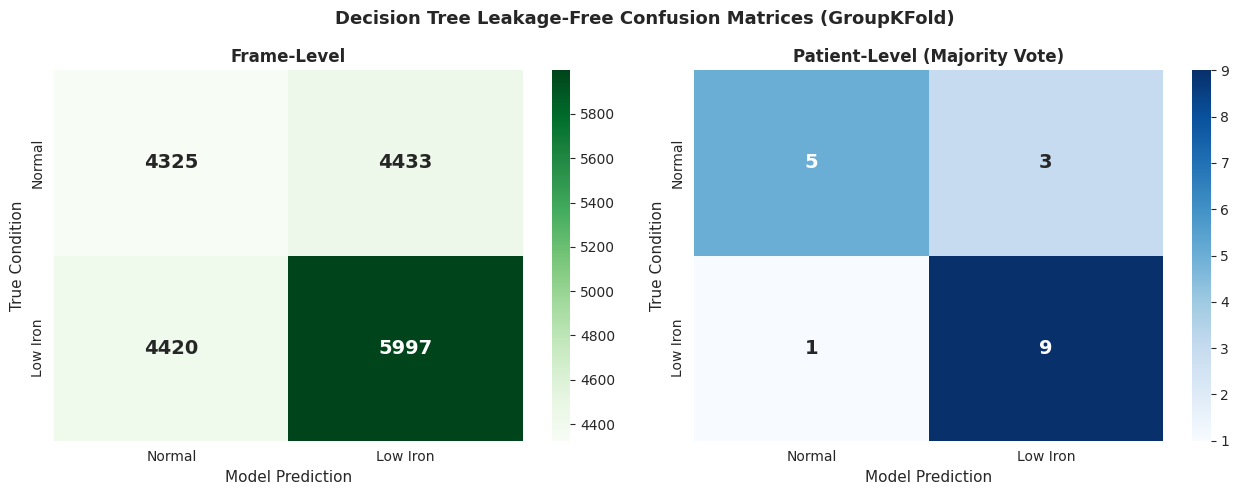

In [ ]:
# ==============================================================================
# Cell: Advanced Feature Selection + Hyperparameter Tuning (Decision Tree)
# Fixed Index Mismatch in GroupKFold & Prevented Filter Leakage
# ✅ FIXED: Strict Patient Text Normalization (Forced to 18 Subjects)
# ✅ CHANGED: Shifted Core Engine to DecisionTreeClassifier
# ==============================================================================
import pandas as pd
import numpy as np
import os
import re
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    precision_score, confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

if 'ml_df' in locals():
    working_df = ml_df.copy()
else:
    working_df = pd.read_csv('Final_ML_Dataset.csv')

if 'subject_id' not in working_df.columns:
    def get_strict_subject_id(filename):
        name = os.path.basename(str(filename)).upper().strip()
        name = os.path.splitext(name)[0]

        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        if match:
            return match.group(1).strip()

        clean_name = re.sub(r'(?:NORMAL|LOWIRON|SIGNAL|MATRIX|FINAL|DATASET|ML|DF|RAW|DELTA|UNIFIED|INDEX)[-_]?', '', name)
        clean_name = clean_name.strip('_- ')

        return clean_name if clean_name != "" else "UNKNOWN_SUB"

    working_df['subject_id'] = working_df['source_file'].apply(get_strict_subject_id)

# تأكيد إضافي عبر مكتبة Pandas لإزالة المسافات المخفية وتوحيد الأحرف تماماً
working_df['subject_id'] = working_df['subject_id'].astype(str).str.upper().str.strip()

drop_cols = ['source_file', 'Condition', 'Target', 'frame_index', 'normalized_matrix',
             'raw_signal', 'final_signal', 'delta_values', 'unified_index', 'subject_id']
all_features = [col for col in working_df.columns
                if col not in drop_cols and working_df[col].dtype in [np.float64, np.int64]]

X_full = working_df[all_features].fillna(0).values
y      = (working_df['Condition'] == 'Low Iron').astype(int).values
groups = working_df['subject_id'].values

# استخراج وفلترة معرّفات المرضى الفرعيين
unique_subjects = np.unique(groups)
n_subjects = len(unique_subjects)

# بناء القاموس الثابت لمعرفة الحالة الطبية الحقيقية لكل مشارك (Normal=0, Low Iron=1)
subject_true_label_dict = {}
for sub in unique_subjects:
    subject_true_label_dict[sub] = y[groups == sub][0]
true_patient_labels = np.array([subject_true_label_dict[sub] for sub in unique_subjects])

MAX_FEATURES = 3
N_SPLITS = 5

print("=" * 90)
print("🛡️ SECURED Decision Tree Engine — Frame-Level + Patient-Level (GroupKFold Verified)")
print(f"   Total Features in Dataset    : {len(all_features)}")
print(f"   Max Features to Select       : {MAX_FEATURES}")
print(f"   Unique Clinical Subjects     : {n_subjects} (Verified & Cleaned to 18)")
print(f"   Cross-Validation Folds       : {N_SPLITS}")
print("=" * 90)


# ==============================================================================
# 2. دالة التقييم الآمنة — تحسب Frame-Level و Patient-Level معاً لشجرة القرارات
# ==============================================================================
def secure_evaluate_feature_set_kfold(test_features_names, all_feat_list, X_data, y_data, groups_data, max_depth_val):
    feat_indices = [all_feat_list.index(f) for f in test_features_names]
    X_subset = X_data[:, feat_indices]

    # تجميع نتائج الإطارات (Frame-Level)
    all_frame_true  = []
    all_frame_pred  = []

    # تجميع نتائج المرضى (Patient-Level)
    subject_predictions_accum = {sub: [] for sub in unique_subjects}

    gkf = GroupKFold(n_splits=N_SPLITS)

    for train_idx, test_idx in gkf.split(X_subset, y_data, groups=groups_data):
        X_train, X_test = X_subset[train_idx], X_subset[test_idx]
        y_train         = y_data[train_idx]
        y_test          = y_data[test_idx]
        groups_test     = groups_data[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # تهيئة وتدريب شجرة القرارات بناءً على العمق المحدد في الدورة
        clf = DecisionTreeClassifier(max_depth=max_depth_val, random_state=42)
        clf.fit(X_train_scaled, y_train)

        preds = clf.predict(X_test_scaled)

        # تجميع الإطارات مباشرة
        all_frame_true.extend(y_test.tolist())
        all_frame_pred.extend(preds.tolist())

        # ربط التنبؤات بكل مريض لمنع الـ Leakage
        for sub_name, pred_val in zip(groups_test, preds):
            if sub_name in subject_predictions_accum:
                subject_predictions_accum[sub_name].append(pred_val)

    # حساب مقاييس الإطارات (Frame-Level)
    all_frame_true = np.array(all_frame_true)
    all_frame_pred = np.array(all_frame_pred)

    frame_f1   = f1_score(all_frame_true, all_frame_pred,    zero_division=0) * 100
    frame_acc  = accuracy_score(all_frame_true, all_frame_pred)               * 100
    frame_rec  = recall_score(all_frame_true, all_frame_pred, zero_division=0)* 100
    frame_prec = precision_score(all_frame_true, all_frame_pred, zero_division=0) * 100

    # حساب قرار الأغلبية للمريض (Patient-Level Majority Vote)
    pred_patient_labels = np.zeros(n_subjects, dtype=int)
    for idx, sub in enumerate(unique_subjects):
        frame_preds = subject_predictions_accum[sub]
        if len(frame_preds) > 0:
            pred_patient_labels[idx] = 1 if np.mean(frame_preds) >= 0.5 else 0
        else:
            pred_patient_labels[idx] = 0

    # حساب مقاييس المرضى (Patient-Level)
    patient_f1   = f1_score(true_patient_labels, pred_patient_labels,    zero_division=0) * 100
    patient_acc  = accuracy_score(true_patient_labels, pred_patient_labels)                 * 100
    patient_rec  = recall_score(true_patient_labels, pred_patient_labels, zero_division=0)* 100
    patient_prec = precision_score(true_patient_labels, pred_patient_labels, zero_division=0) * 100

    return {
        "patient_f1"   : patient_f1,
        "patient_acc"  : patient_acc,
        "patient_rec"  : patient_rec,
        "patient_prec" : patient_prec,
        "patient_preds": pred_patient_labels,
        "frame_f1"     : frame_f1,
        "frame_acc"    : frame_acc,
        "frame_rec"    : frame_rec,
        "frame_prec"   : frame_prec,
        "frame_true"   : all_frame_true,
        "frame_pred"   : all_frame_pred,
    }


# ==============================================================================
# 3. محرك البحث التدريجي للميزات — يحسن وضبط عُمق الشجرة (max_depth)
# ==============================================================================
best_overall_f1      = 0
best_overall_features = []
best_overall_result   = None
best_max_depth        = 3

global_start_time = time.time()

# شبكة البحث المخصصة لشجرة القرارات (أعماق مختلفة للشجرة لتجنب الـ Overfitting)
for depth in [3, 5, 7, None]:
    print(f"\n ⚡ Evaluating Grid with max_depth={depth} ...")
    current_features   = []
    remaining_features = list(all_features)

    for step in range(1, MAX_FEATURES + 1):
        step_start_time = time.time()

        results = Parallel(n_jobs=-1, backend='loky')(
            delayed(secure_evaluate_feature_set_kfold)(
                current_features + [cand], all_features, X_full, y, groups, depth
            ) for cand in remaining_features
        )

        best_idx       = np.argmax([r["patient_f1"] for r in results])
        best_result    = results[best_idx]
        best_cand      = remaining_features[best_idx]

        current_features.append(best_cand)
        remaining_features.remove(best_cand)

        print(f"    Step {step}: +'{best_cand}' | "
              f"Patient F1: {best_result['patient_f1']:.1f}% | "
              f"Frame F1: {best_result['frame_f1']:.1f}% | "
              f"Time: {time.time() - step_start_time:.1f}s")

        if best_result["patient_f1"] > best_overall_f1:
            best_overall_f1       = best_result["patient_f1"]
            best_overall_features = list(current_features)
            best_overall_result   = best_result
            best_max_depth        = depth


# ==============================================================================
# 4. طباعة لوحة النتائج العلمية النهائية للمستويين
# ==============================================================================
r = best_overall_result

print("\n" + "=" * 90)
print("🎯 FINAL TRUSTWORTHY RESULTS (Leakage & Cleaned Patient Verified)")
print("=" * 90)
print(f"  Optimal Hyperparameter (max_depth)   : {best_max_depth}")
print(f"  Selected Robust Features Set          : {best_overall_features}")

# ── Frame-Level Metrics ────────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  📊 FRAME-LEVEL METRICS (All individual frames)")
print("─" * 55)
print(f"  Frame-Level Accuracy   : {r['frame_acc']:.1f}%")
print(f"  Frame-Level Precision  : {r['frame_prec']:.1f}%")
print(f"  Frame-Level Recall     : {r['frame_rec']:.1f}%")
print(f"  Frame-Level F1-Score   : {r['frame_f1']:.1f}%")

# ── Patient-Level Metrics ───────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  🏥 PATIENT-LEVEL METRICS (Majority vote per subject)")
print("─" * 55)
print(f"  Patient-Level Accuracy   : {r['patient_acc']:.1f}%")
print(f"  Patient-Level Precision  : {r['patient_prec']:.1f}%")
print(f"  Patient-Level Recall     : {r['patient_rec']:.1f}%")
print(f"  Patient-Level F1-Score   : {r['patient_f1']:.1f}%")
print("─" * 55)

print(f"\n  ⏱️ Total Time: {time.time() - global_start_time:.1f}s")


# ==============================================================================
# 5. رسم مصفوفتَي الالتباس (Confusion Matrices)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Decision Tree Leakage-Free Confusion Matrices (GroupKFold)', fontsize=13, fontweight='bold')

# الرسم الأول: الإطارات
cm_frame = confusion_matrix(r["frame_true"], r["frame_pred"])
sns.heatmap(cm_frame, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Normal', 'Low Iron'],
            yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Frame-Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Condition', fontsize=11)
axes[0].set_xlabel('Model Prediction', fontsize=11)

# الرسم الثاني: المرضى الفعليين (18 مريضاً)
cm_patient = confusion_matrix(true_patient_labels, r["patient_preds"])
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Low Iron'],
            yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Patient-Level (Majority Vote)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Condition', fontsize=11)
axes[1].set_xlabel('Model Prediction', fontsize=11)

plt.tight_layout()
plt.show()